# Feature Evaluation Across Case Studies

**Docker image**: `ml4t`

Each case study runs an FDR-controlled triage pass on its candidate
feature menu (Ch8 §8.5), classifying every feature as PROCEED, REVISE,
or STOP. This notebook reads those nine ledgers side by side and asks
whether feature-level survival predicts strategy-level survival once
the rest of the pipeline runs.

The forward link is the point. §03 (signal quality) and §04
(signal-to-strategy) build on whatever this notebook surfaces.

**Book Reference**: Chapter 20, Section 20.2.

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb)
first. Each case study's `case_studies/{cs}/evaluation/triage_ledger.parquet`
must exist (regenerated by the per-case-study `05_evaluation` notebooks).

In [1]:
"""Ch20 Feature Evaluation — cross-case-study triage ledger comparison."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

warnings.filterwarnings("ignore")

from case_studies.utils.analytics import CASE_STUDY_IDS, SHORT_NAMES
from utils.paths import REPO_ROOT, get_chapter_dir

In [2]:
MAX_CASE_STUDIES = 0  # 0 = all available

In [3]:
OUTPUT_DIR = get_chapter_dir(20) / "output"

CS_LIST = CASE_STUDY_IDS[:MAX_CASE_STUDIES] if MAX_CASE_STUDIES else CASE_STUDY_IDS

## 1. Load Triage Ledgers

Each per-CS ledger has the same schema: one row per candidate feature,
columns for IC moment estimates, HAC-adjusted t-statistic, BH-FDR
p-value, fold sign consistency, monotonicity, coverage, and a final
categorical decision in {PROCEED, REVISE, STOP}.

In [4]:
def _load_ledger(cs: str) -> pl.DataFrame | None:
    p = REPO_ROOT / "case_studies" / cs / "evaluation" / "triage_ledger.parquet"
    if not p.exists():
        return None
    return pl.read_parquet(p).with_columns(case_study=pl.lit(cs))


ledgers = {cs: _load_ledger(cs) for cs in CS_LIST}
available = [cs for cs, df in ledgers.items() if df is not None]
missing = [cs for cs in CS_LIST if cs not in available]
print(f"Loaded {len(available)}/{len(CS_LIST)} ledgers")
if missing:
    print(f"Missing: {missing}")

_frames = [
    df.select(["feature", "fdr_sig", "decision", "case_study"])
    for df in ledgers.values()
    if df is not None
]
if _frames:
    panel = pl.concat(_frames, how="vertical_relaxed")
else:
    panel = pl.DataFrame(
        schema={
            "feature": pl.Utf8,
            "fdr_sig": pl.Boolean,
            "decision": pl.Utf8,
            "case_study": pl.Utf8,
        }
    )

Loaded 9/9 ledgers


## 2. The Triage Funnel

For each case study: candidates considered → features that clear BH-FDR
at 5 percent → features that earn a final PROCEED decision (FDR-significant
*and* monotonic *and* with stable sign across folds). The gap between
`fdr_sig` and `PROCEED` shows how many features survived single-test
scrutiny but failed the additional shape and stability checks.

In [5]:
funnel = (
    panel.group_by("case_study")
    .agg(
        n_candidate=pl.len(),
        n_fdr_sig=pl.col("fdr_sig").sum(),
        n_proceed=(pl.col("decision") == "PROCEED").sum(),
    )
    .with_columns(
        pct_fdr_sig=(pl.col("n_fdr_sig") / pl.col("n_candidate") * 100).round(1),
        pct_proceed=(pl.col("n_proceed") / pl.col("n_candidate") * 100).round(1),
        cs_short=pl.col("case_study").replace(SHORT_NAMES),
    )
    .sort("pct_proceed", descending=True)
)
funnel.select(["cs_short", "n_candidate", "n_fdr_sig", "n_proceed", "pct_fdr_sig", "pct_proceed"])

cs_short,n_candidate,n_fdr_sig,n_proceed,pct_fdr_sig,pct_proceed
str,u32,u32,u32,f64,f64
"""Crypto""",45,32,32,71.1,71.1
"""US Firms""",57,38,40,66.7,70.2
"""ETFs""",71,1,17,1.4,23.9
"""CME Futures""",69,6,13,8.7,18.8
"""FX""",61,4,10,6.6,16.4
"""SP500 Options""",51,4,6,7.8,11.8
"""SP500 Eq+Opt""",49,0,4,0.0,8.2
"""NQ100""",88,4,4,4.5,4.5
"""US Equities""",73,0,0,0.0,0.0


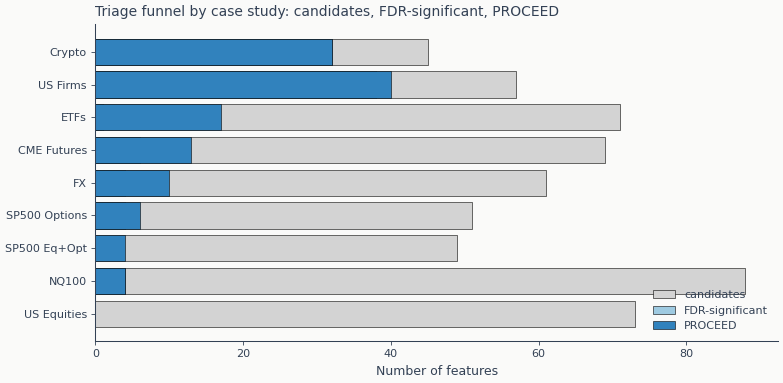

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(funnel.height)
ax.barh(
    y,
    funnel["n_candidate"].to_numpy(),
    color="lightgrey",
    label="candidates",
    edgecolor="black",
    linewidth=0.4,
)
ax.barh(
    y,
    funnel["n_fdr_sig"].to_numpy(),
    color="#9ecae1",
    label="FDR-significant",
    edgecolor="black",
    linewidth=0.4,
)
ax.barh(
    y,
    funnel["n_proceed"].to_numpy(),
    color="#3182bd",
    label="PROCEED",
    edgecolor="black",
    linewidth=0.4,
)
ax.set_yticks(y)
ax.set_yticklabels(funnel["cs_short"].to_numpy())
ax.invert_yaxis()
ax.set_xlabel("Number of features")
ax.set_title("Triage funnel by case study: candidates, FDR-significant, PROCEED")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.show()

Two case studies (Crypto and US Firms) clear FDR for roughly
two-thirds of their candidate features. The other seven clear FDR for
under 10 percent of candidates, and two (SP500 Eq+Opt and US
Equities) clear it for none. The spread runs from 0 to 71 percent
under the same triage protocol; what varies is the asset class, not
the procedure. US Equities is the most extreme low-end case — its
candidate menu draws on the same generic financial-features library
as the other equity panels, but at the 1-day horizon and broad-cap
universe none of the 73 single-feature IC tests clears BH-FDR. The
downstream ML model still trains on those features and the carrier
configuration publishes a positive validation Sharpe (NB00), which
illustrates that single-feature univariate IC tests and multi-feature
joint prediction can disagree by design.

## 3. Forward Link: Feature Survival vs Strategy Survival

Pair each case study's PROCEED rate against the carrier configuration's
validation Sharpe and holdout Sharpe from §01. The triage ledger is upstream of
every model and backtest, so this is the cleanest test of whether richer
feature menus produce stronger downstream strategies.

In [7]:
mq = pl.read_parquet(OUTPUT_DIR / "measurement_quality.parquet")
forward = (
    funnel.select(["case_study", "cs_short", "pct_proceed"])
    .join(
        mq.select(
            pl.col("cs_id").alias("case_study"),
            "rank1_val_sharpe",
            "holdout_sharpe",
        ),
        on="case_study",
        how="left",
    )
    .sort("pct_proceed", descending=True)
)
forward

case_study,cs_short,pct_proceed,rank1_val_sharpe,holdout_sharpe
str,str,f64,f64,f64
"""crypto_perps_funding""","""Crypto""",71.1,2.090074,-0.132334
"""us_firm_characteristics""","""US Firms""",70.2,2.754197,1.771001
"""etfs""","""ETFs""",23.9,0.887831,1.002065
"""cme_futures""","""CME Futures""",18.8,0.956424,1.111567
"""fx_pairs""","""FX""",16.4,-0.004311,0.193912
"""sp500_options""","""SP500 Options""",11.8,0.15982,0.973553
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",8.2,1.246553,-0.727829
"""nasdaq100_microstructure""","""NQ100""",4.5,1.127833,0.525317
"""us_equities_panel""","""US Equities""",0.0,1.867508,-0.492209


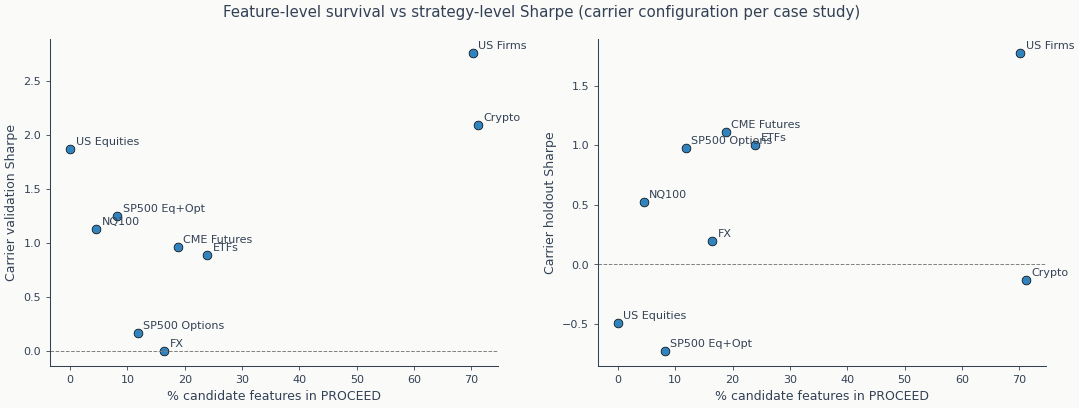

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
for ax, ycol, ylabel in zip(
    axes,
    ["rank1_val_sharpe", "holdout_sharpe"],
    ["Carrier validation Sharpe", "Carrier holdout Sharpe"],
):
    pts = forward.filter(pl.col(ycol).is_not_null()).to_pandas()
    ax.scatter(
        pts["pct_proceed"], pts[ycol], color="#3182bd", s=40, edgecolor="black", linewidth=0.5
    )
    for _, row in pts.iterrows():
        ax.annotate(
            row["cs_short"],
            (row["pct_proceed"], row[ycol]),
            fontsize=8,
            xytext=(4, 3),
            textcoords="offset points",
        )
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.7)
    ax.set_xlabel("% candidate features in PROCEED")
    ax.set_ylabel(ylabel)
fig.suptitle(
    "Feature-level survival vs strategy-level Sharpe (carrier configuration per case study)"
)
fig.tight_layout()
fig.show()

The two high-PROCEED case studies bracket much of the holdout-Sharpe
range: US Firms posts the strongest holdout Sharpe in the panel,
while Crypto's holdout Sharpe sits well below its own validation
Sharpe. The lower-PROCEED band is similarly mixed: CME and ETFs
produce respectable holdout Sharpes despite under 10 percent of
features clearing FDR; NASDAQ-100, FX, US Equities, and SP500
variants do not. What appears to matter more than the count of
surviving features is the economic size of those features relative
to per-period frictions and the way they are turned into positions,
taken up in §03 and §04.

## Takeaways

- PROCEED rates span 0–71 percent under the same triage protocol;
  the spread is asset-class-driven.
- The high-PROCEED case studies do not bracket the strongest holdout
  Sharpes — feature triage is a screen, not a predictor of strategy
  survival.
- Single-feature univariate IC tests and multi-feature joint
  prediction can disagree (US Equities is the clearest case: 0/73
  features clear FDR but the carrier ML model still publishes a
  positive validation Sharpe).
- §03 and §04 take the surviving signal forward into model evidence
  and IC-to-Sharpe translation.